In [1]:
import sys; sys.path.append("../../"); sys.path.append("../../../.."); sys.path.append("../../../gmsh/"); sys.path.append("../../experiments/"); sys.path.append("../../../")
import experiment_helper
import igl
from periodic_simulation_setup import *
import json



In [2]:
a = 2
avg_len = 0.08
radius = 0.8

In [3]:
ih = 1.3
iw = 0.9
h = 5

In [4]:

# time = '2024_01_14_11_09'
# name = 'square_with_ellipse_hole_angle_height_1.6_width_1'


# time = '2024_01_17_09_06'
# name = 'square_with_ellipse_hole_angle_width_with_height_1.6'

time = '2024_01_17_11_33'
name = 'square_with_ellipse_hole_angle_width_height'
experiment_file = '../../experiments/parallelized_experiments/output/{}/{}/experiment_result.json'.format(name, time)
stiffness_path = '../../experiments/parallelized_experiments/output/{}/{}'.format(name, time)

In [5]:
import MeshFEM, visualization

In [6]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

In [7]:
angles = np.linspace(0, 45, 16)[2:]
widths = np.linspace(0.1, 0.9, 9)
heights = np.linspace(1.3, 1.8, 6)

In [8]:
label = "{:.2f}_{:.2f}_{:.2f}".format(angles[10], widths[3], heights[3])

In [13]:
label = '42.00_0.20_1.30'

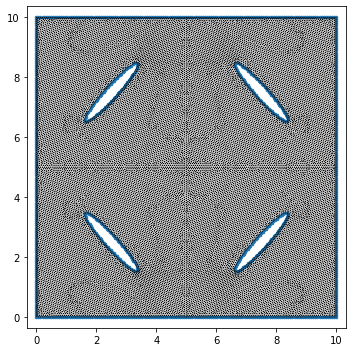

In [23]:
m = MeshFEM.mesh.Mesh('../../experiments/parallelized_experiments/output/{}/{}/{}/mesh_{}_{}.obj'.format(name, time, label, name, label))
fusing_vtx = np.load('../../experiments/parallelized_experiments/output/{}/{}/{}/fusedVtx_{}_{}.npy'.format(name, time, label, name, label))

for vi in m.boundaryVertices():
    fusing_vtx[vi] = True
    
visualization.plot_2d_mesh(m, pointList=fusing_vtx, width=5, height=5)

In [24]:
vertices = m.vertices()
vertices = np.concatenate((vertices, np.zeros((len(vertices), 1))), axis = 1)
m = MeshFEM.mesh.Mesh(vertices, m.elements())
# fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)

ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = fusing_vtx, epsilon = 1e-9)
# ipu.setVars(np.load('../../experiments/parallelized_experiments/output/{}/{}/{}/{}_dofs_before_stiffness_{}.npy'.format(name, time, label, name, label)))

In [25]:
viewer = TriMeshViewer(ipu, width=500, height=500)
viewer.showWireframe(False)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
viewer.show()

Renderer(camera=PerspectiveCamera(children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), quaternion=(…

In [32]:
tag = 'elliptic_holes_max_min_stretching_stiffness_{}'.format(label)

In [33]:
import os

In [34]:
output_folder = 'selected_patterns/{}/'.format(tag)
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [35]:
import parametrization_helper

In [36]:
parametrization_helper.export_top_bottom_mesh(ipu.sheet, output_folder, tag, 'selected')

m.save("{}/mesh_{}.obj".format(output_folder, tag))
np.save("{}/fusedVtx_{}.npy".format(output_folder, tag), fusing_vtx)

In [ ]:
render = viewer.offscreenRenderer(1000, 1000)
render.render()
render.save("{}/{}_render_{}_{}.png".format(result_folder, '', name, variable))

In [ ]:
name = "isotropy"
time_stamp = time.strftime("%Y_%m_%d_%H_%M")
result_folder = 'output/{}/{}'.format(name, time_stamp)
if not os.path.exists(result_folder):
    os.makedirs(result_folder)  
    
variable = radius

In [ ]:
import importlib, periodic_simulation_setup

In [ ]:
importlib.reload(periodic_simulation_setup)

In [ ]:
points = periodic_simulation_setup.visualize_average_deformation_gradient(ipu, 100, plot_max_r=1, plot_min_r=0, show_figure=True, filename = "{}/average_deformation_gradient_{}_{}.svg".format(result_folder, name, variable))

In [ ]:
az_ipu = get_az_ipu_from_ipu(ipu, m, fusedVtx, useTFT, disableFusedRegionTFT)
if not allowBending:
    fixedVars, hessianShift = [az_ipu.numVars() - 2, az_ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6
opts.niter = 1000
az_optimizer = inflation.get_inflation_optimizer(az_ipu, fixedVars, opts, callback=None, hessianShift = hessianShift)
# cr = az_optimizer.optimize()

In [ ]:
stiffness_shift = 1e-15
success = False
for i in range(15):
    try:
        stiffness_values, sampled_alphas, stiffness_coefficient = periodic_simulation_setup.visualize_sampled_bending_stiffness(az_ipu, 1000, az_optimizer, hessianShift = stiffness_shift, fixedVars = [], filename = "{}/stiffness_{}_{}.svg".format(result_folder, name, variable), show_figure=True, plot_min_r=0)
        np.save("{}/stiffness_values_{}_{}.npy".format(result_folder, name, variable), stiffness_values)
        np.save("{}/sampled_alphas_{}_{}.npy".format(result_folder, name, variable), sampled_alphas)
        np.save("{}/stiffness_coefficient_{}_{}.npy".format(result_folder, name, variable), stiffness_coefficient)
        print("Solved using stiffness shift: ", stiffness_shift)
        success = True
        break
    except:
        print("failed to compute stiffness with shift ", stiffness_shift)
        stiffness_shift *= 10
if (not success):
    print("Failed to solve stiffness!")


In [ ]:
low_pressure_tag = "low_pressure"

In [ ]:
np.save("{}/scale_factors_{}_{}.npy".format(result_folder, name, variable), get_deformation_scale_factors(az_ipu.ipu))
np.save("{}/kappa_{}_{}.npy".format(result_folder, name, variable), az_ipu.getVars()[-2])

np.save("{}/average_deformation_gradient_matrix_{}_{}.npy".format(result_folder, name, variable), get_deformation_matrix(az_ipu.ipu))

np.save("{}/{}_strain_values_{}_{}.npy".format(result_folder, low_pressure_tag, name, variable), utils.getStrains(az_ipu.ipu.sheet)[:, 0])

np.save("{}/{}_dofs_{}_{}.npy".format(result_folder, low_pressure_tag, name, variable), az_ipu.getVars())

In [ ]:
viewer.saveObj("{}/mesh_{}_{}.obj".format(result_folder, name, variable))

In [ ]:
viewer.saveColorizedObj("{}/color_mesh_{}_{}.obj".format(result_folder, name, variable))